In [45]:
pwd

'/Volumes/E/Self Study Agentic AI/Lang Graph'

# BMI Calculator  (Not LLM workflow)
BMI = Weight (kg) ÷ [Height (m)]²

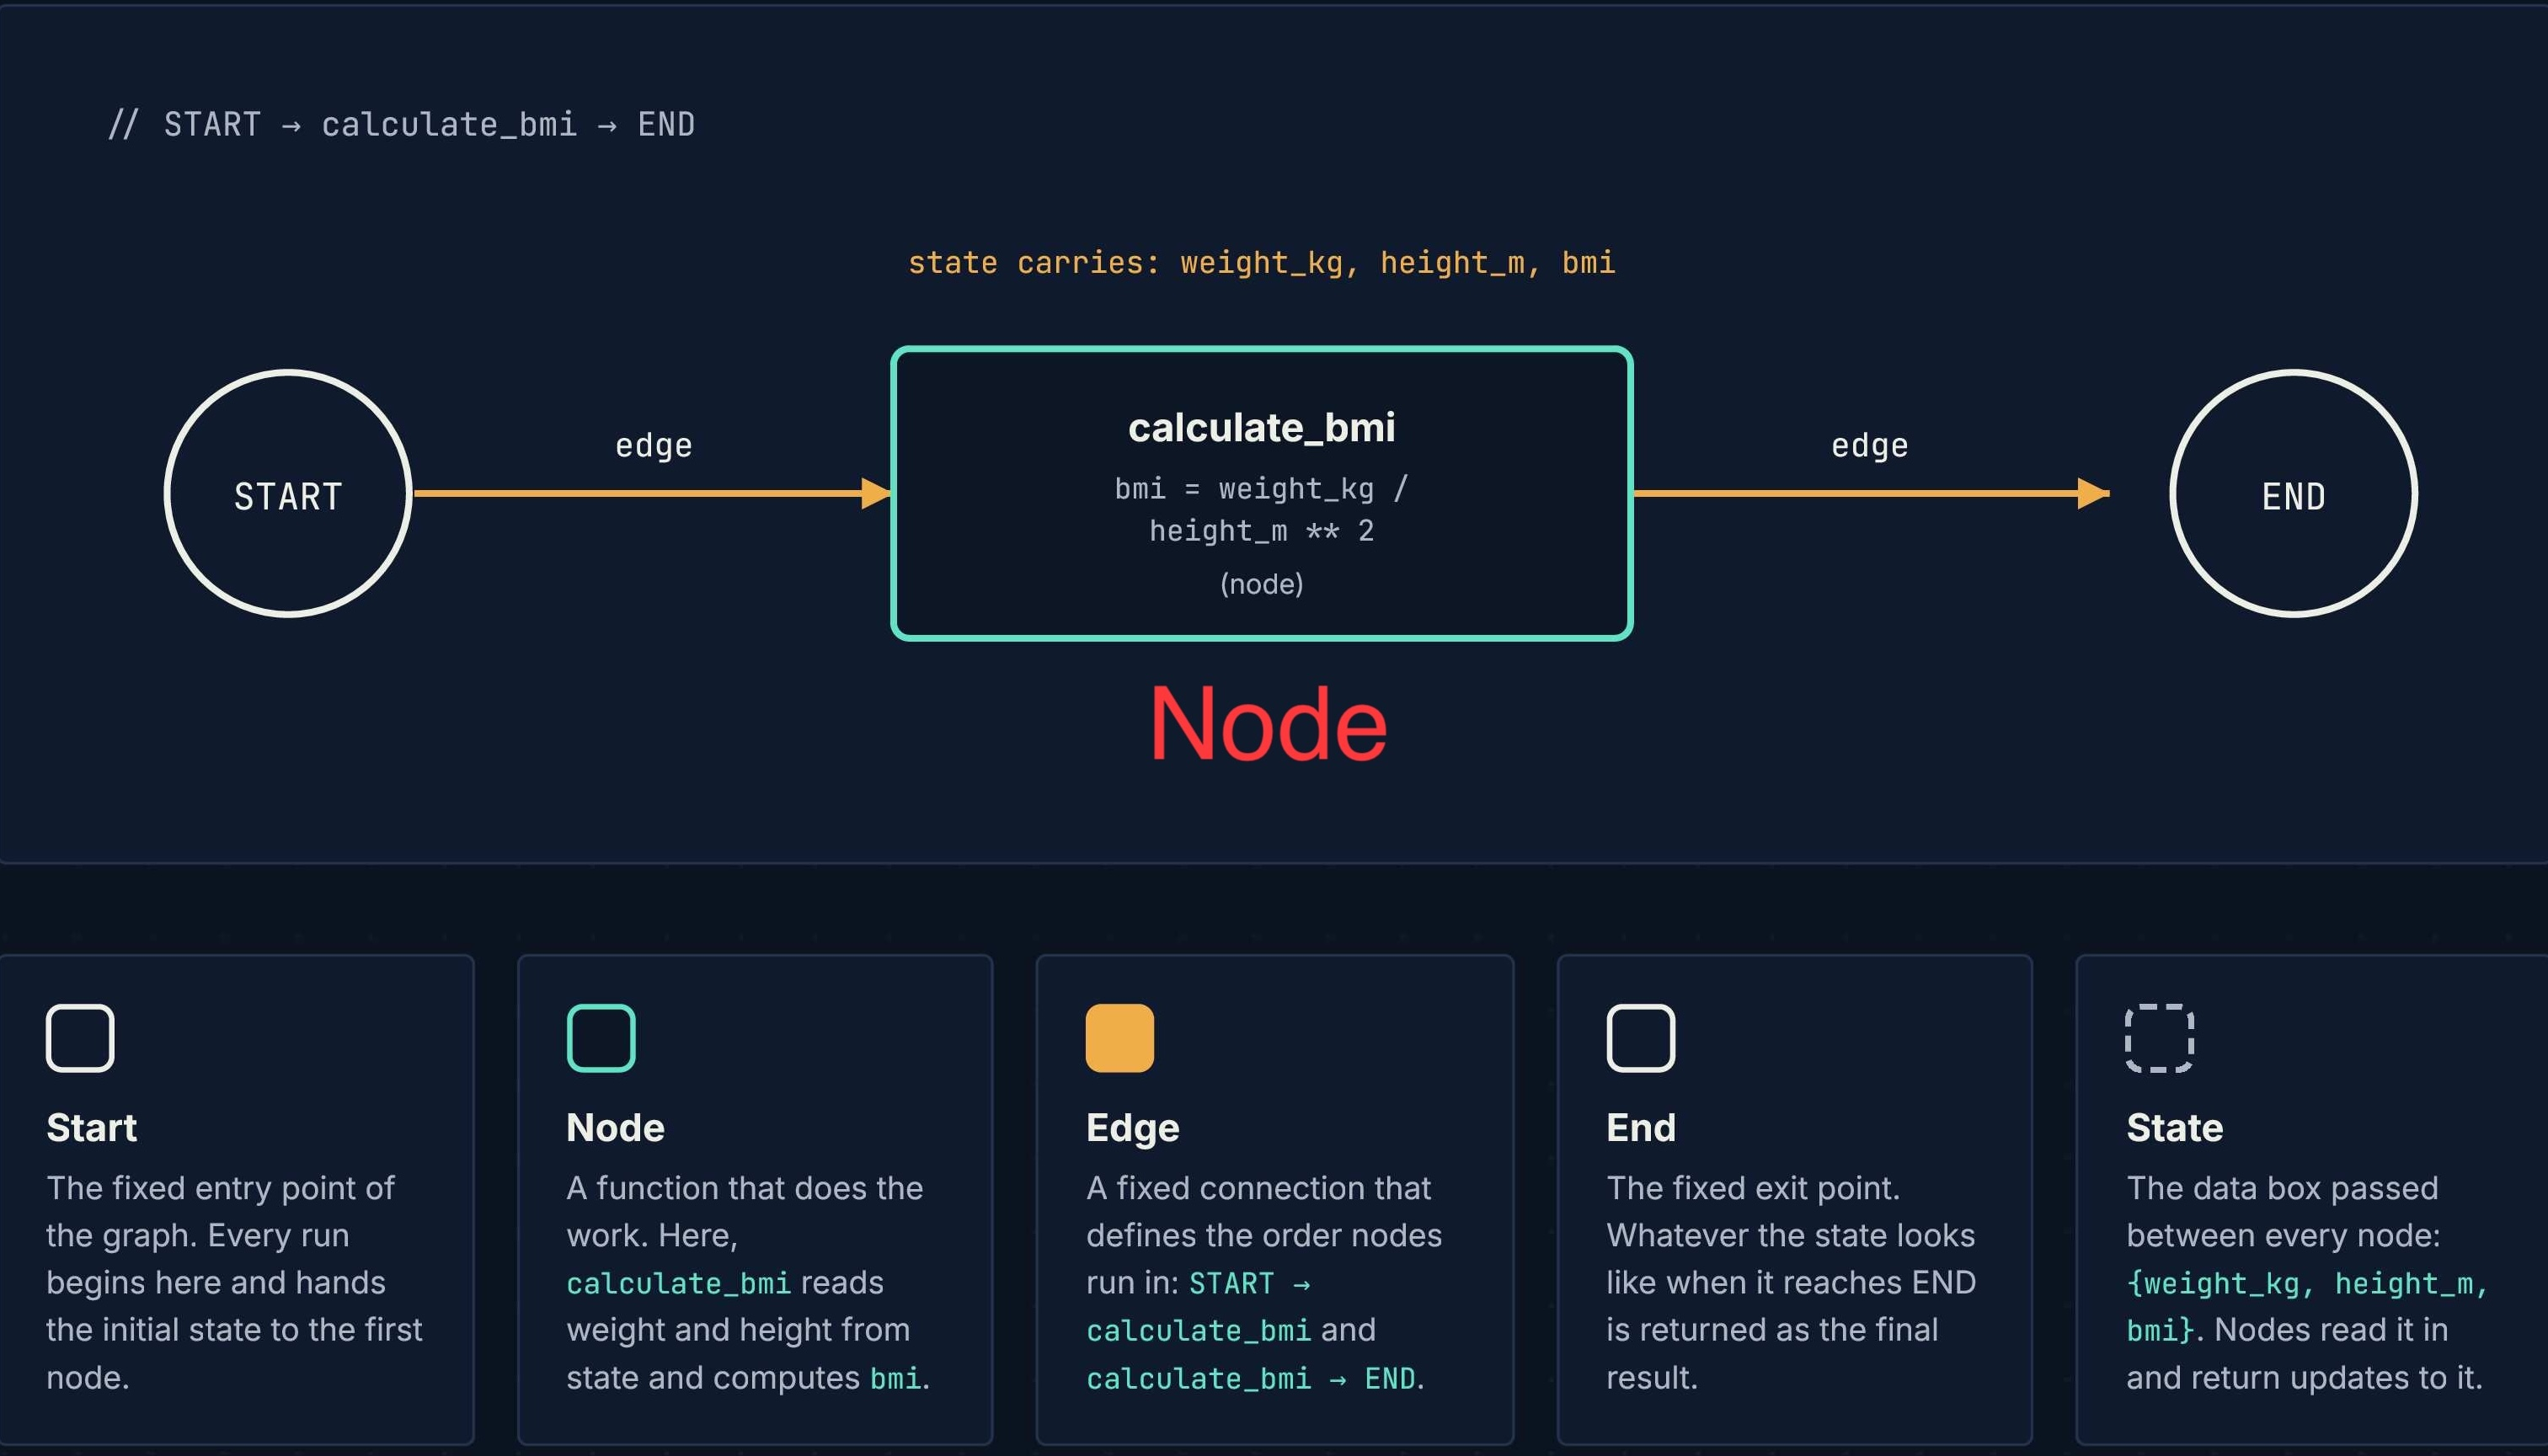

In [58]:
from IPython.display import Image
Image(filename="image/bmi_calculator_langgraph_diagram.jpg")

# LangGraph Workflow — 7 Basic Steps

| Step | What we do | Example |
|---|---|---|
| **Step 1: Define State** | Define the data that flows through the graph | `BMIState` |
| **Step 2: Define Functions** | Create the logic/business operation | `calculate_bmi()` |
| **Step 3: Define Graph** | Create the LangGraph workflow | `StateGraph(BMIState)` |
| **Step 4: Add Nodes** | Add functions/tasks to the graph | `add_node(Name of the node,Function that the node will execute)` |
| **Step 5: Add Edges** | Connect nodes and define the flow/direction of the workflow | `add_edge(start node,end node)` |
| **Step 6: Compile Graph** | Convert the graph into an executable workflow | `graph.compile()` |
| **Step 7: Invoke/Execute** | Run the workflow with input state | `workflow.invoke()` |

## 🧠 Easy Way to Remember

**State → Function → Graph → Nodes → Edges → Compile → Invoke**

### BMI Example Workflow
```text
Step 1 → BMIState
           ↓
Step 2 → calculate_bmi()
           ↓
Step 3 → StateGraph(BMIState)
           ↓
Step 4 → add_node()
           ↓
Step 5 → START → calculate_bmi → END
           ↓
Step 6 → graph.compile()
           ↓
Step 7 → workflow.invoke(initial_state)

```
### One-Line Definition

> **State = Data, Function = Logic, Node = Task, Edge = Flow, Compile = Prepare, Invoke = Execute.**

#install package only first time
#pip install langgraph

In [48]:
#Define Library
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

**Why do we need State?**

LangGraph works by passing state from one node to another.<br>
state as a box containing all input and output information.

In [49]:
#Define State
class BMIState(TypedDict):
    weight_kg:float
    height_m:float
    bmi: float

In [50]:
def calculate_bmi(state: BMIState) -> BMIState:
    #fetch state objects
    weight = state['weight_kg']
    height = state['height_m']
    bmi = weight /(height**2)

    #update the state
    state['bmi']=round(bmi,2)
    
    return state

In [51]:
#Define graph
graph=StateGraph(BMIState) #create object for graph

#add notes to the graph
#Create a node called calculate_bmi and execute the calculate_bmi function when this node runs.
graph.add_node('calculate_bmi',calculate_bmi)

#add edges to the graph
graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi',END)

#compile the graph
workflow=graph.compile()

#execute the graph
intial_state = {'weight_kg':80, 'height_m':1.73}
final_state=workflow.invoke(initial_state)
print(final_state)

{'weight_kg': 80, 'height_m': 1.73, 'bmi': 26.73}


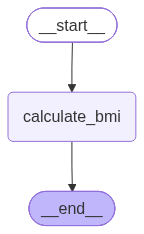

In [52]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())